<a href="https://colab.research.google.com/github/anika140/anika140/blob/main/ecg_week1_mitbih.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wfdb neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 45.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import wfdb
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Extracting Record '100' from the MIT-BIH Arrhythmia Database
# Primarily exhibits a relatively stable Normal Sinus Rhythm
# pn_dir='mitdb' tells wfdb to pull directly from PhysioNet withuot manual download
record = wfdb.rdrecord('100', pn_dir='mitdb')

print("Leads available:", record.sig_name)
print("Sampling rate:", record.fs, "Hz")
print("Total samples:", record.p_signal.shape[0])
print("Duration:", round(record.p_signal.shape[0] / record.fs / 60, 1), "minutes")


Leads available: ['MLII', 'V5']
Sampling rate: 360 Hz
Total samples: 650000
Duration: 30.1 minutes


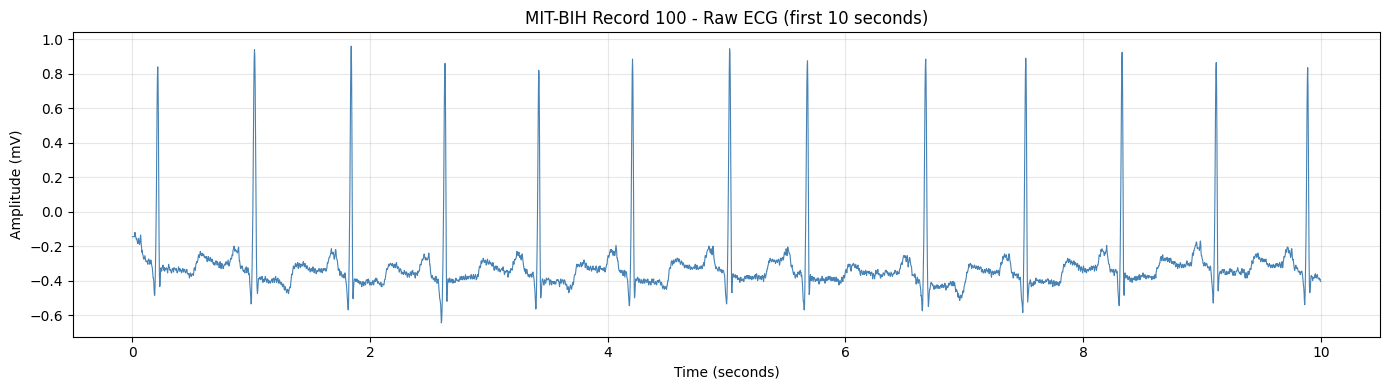

In [4]:
# We're pulling out lead MLII and looking at the first 10 seconds

fs = record.fs
ecg_raw = record.p_signal[:, 0]

ten_seconds = 10 * fs     # 10 seconds x 360 samles/sec = 3600 samples
time = np.arange(ten_seconds) / fs     # time axis in seconds

plt.figure(figsize=(14,4))
plt.plot(time, ecg_raw[:ten_seconds], color='steelblue', linewidth=0.8)
plt.title("MIT-BIH Record 100 - Raw ECG (first 10 seconds)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


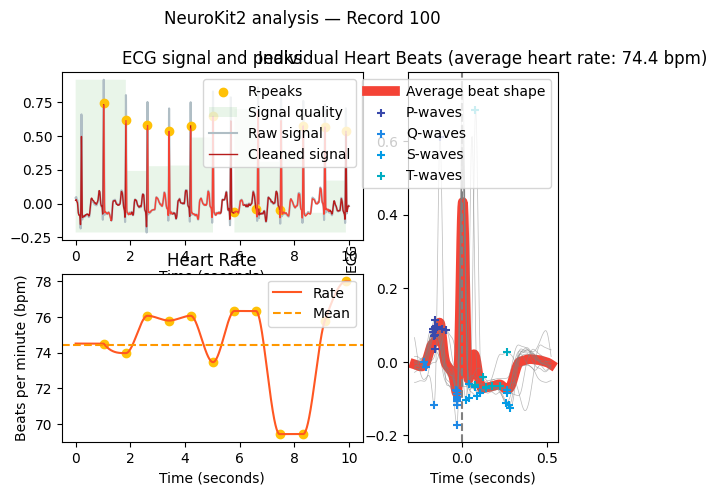

In [6]:
ecg_cleaned = nk.ecg_clean(ecg_raw[:ten_seconds], sampling_rate=fs)
signals, info = nk.ecg_process(ecg_cleaned, sampling_rate=fs)

nk.ecg_plot(signals, info)
plt.suptitle("NeuroKit2 analysis — Record 100", y=1.01)
plt.show()

In [8]:
heart_rate = signals["ECG_Rate"]

print("=== Heart Rate Summary ===")
print(f"Mean: {heart_rate.mean():.1f} BPM")
print(f"Min: {heart_rate.min():.1f} BPM")
print(f"Max: {heart_rate.max():.1f} BPM")
print(f"Std: {heart_rate.std():.1f} BPM")
print(f"Beats detected: {len(info['ECG_R_Peaks'])}")

=== Heart Rate Summary ===
Mean: 74.4 BPM
Min: 69.5 BPM
Max: 78.0 BPM
Std: 2.3 BPM
Beats detected: 12


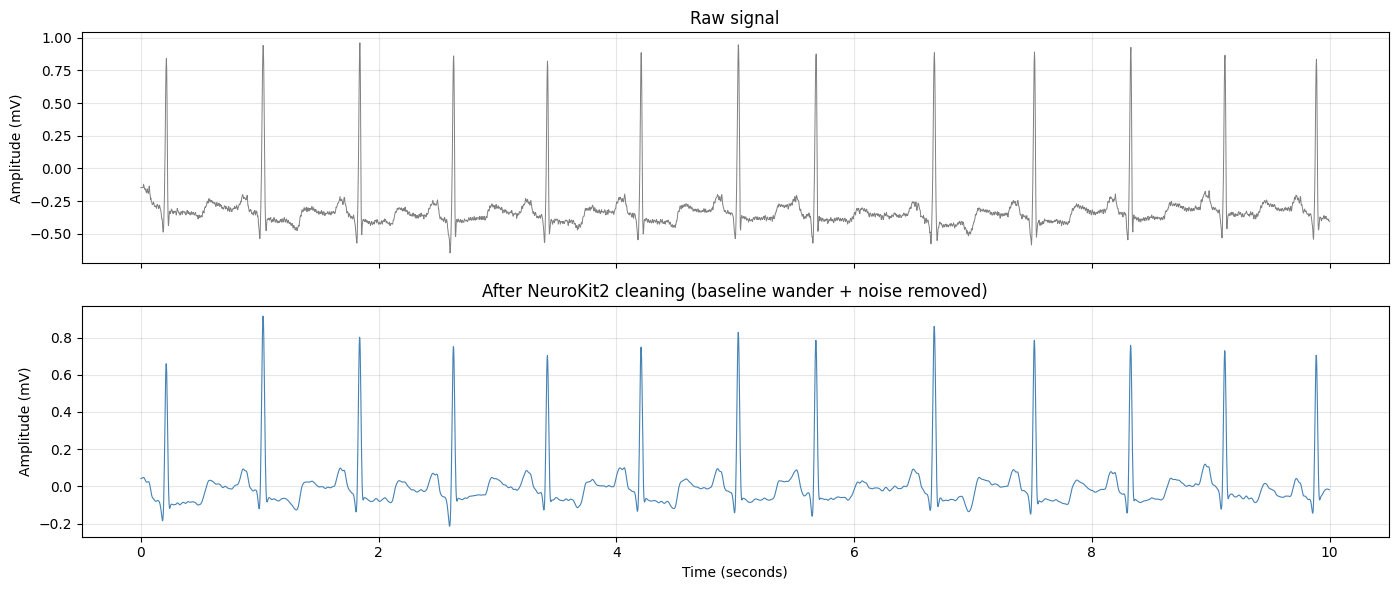

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(time, ecg_raw[:ten_seconds], color='gray', linewidth=0.7, label='Raw')
ax1.set_title("Raw signal")
ax1.set_ylabel("Amplitude (mV)")
ax1.grid(True, alpha=0.3)

ax2.plot(time, ecg_cleaned, color='steelblue', linewidth=0.8, label='Cleaned')
ax2.set_title("After NeuroKit2 cleaning (baseline wander + noise removed)")
ax2.set_xlabel("Time (seconds)")
ax2.set_ylabel("Amplitude (mV)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()